# Tahap 6 — Pilot Resolusi Patch (Skenario S2)

Mengikuti Subbab 2.2.4, 3.5, dan 3.6.3 naskah proposal.

**Skenario ini bukan eksperimen seleksi.** Ukuran patch untuk analisis primer sudah ditetapkan di
muka oleh aturan fisiologis pada Subbab 3.5 — patch harus lebih pendek daripada satu siklus tremor
7 Hz, yaitu 143 milidetik — dan analisis primer pada Subbab 3.6.7 sudah mengunci "patch halus".
Memilih ukuran patch berdasarkan AUC berarti menetapkan parameter dari hasil, padahal aturannya
sudah ditetapkan sebelumnya.

Tiga tugas skenario ini:

1. **Menguji prediksi Subbab 2.2.4.** Naskah memprediksi keunggulan Bidirectional Mamba-2 hanya
   relevan pada urutan panjang, dan tidak muncul pada resolusi patch kasar. Sapuan ini mengubah
   panjang urutan hampir 14 kali lipat, sehingga prediksi itu dapat diuji langsung.
2. **Memastikan resolusi halus layak dilatih**, bukan sekadar diinginkan.
3. **Menetapkan batas epoch** dari kurva konvergensi, untuk dibekukan sebelum eksperimen utama
   sesuai protokol pembekuan pada Subbab 3.6.1.

In [9]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter, NullLocator
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from preprocessing import muat_cache, Normalisasi, rekayasa_kanal, KANAL_MODEL
from model import PDClassifier
from training import latih, prediksi, metrik_biner
from metrics import gini
from viz import WARNA, TINTA, pasang_gaya, rapikan, pita_tremor

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
FS = 100
PATCH = [4, 7, 14, 56]       # 40, 70, 140, 560 ms
EPOCHS = 50                  # anggaran longgar; batas sesungguhnya ditetapkan dari kurva konvergensi
SEED = 0
SIKLUS_MS = 1000 / 7         # satu siklus tremor pada 7 Hz

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s2_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
print(f"perangkat: {DEV} | {len(rek)} rekaman, {len(set(grup))} subjek")
print(f"satu siklus tremor 7 Hz = {SIKLUS_MS:.0f} ms = {SIKLUS_MS/10:.1f} sampel pada {FS} Hz")

def sumbu_patch(ax):
    ax.set_xscale("log"); ax.set_xticks(PATCH)
    ax.set_xticklabels([f"{p}\n({p*10} ms)" for p in PATCH])
    ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim(PATCH[0] * 0.75, PATCH[-1] * 1.35)
    ax.set_xlabel("ukuran patch (sampel)")

perangkat: cuda | 207 rekaman, 77 subjek
satu siklus tremor 7 Hz = 143 ms = 14.3 sampel pada 100 Hz


## 1. Apa yang sebenarnya membawa tremor ke tingkat patch

Sebelum menjalankan sapuan, satu hal perlu diluruskan karena menentukan cara membaca seluruh hasil
sesudahnya.

Osilasi tremor bernilai rata-rata nol. Setiap kali sebuah patch merata-ratakan langkah waktu di
dalamnya, komponen berrerata nol itu saling meniadakan — dan peniadaannya sempurna ketika lebar
patch merupakan kelipatan bulat periode tremor. Dugaan yang wajar dari sini: patch selebar satu
siklus adalah pilihan terburuk.

Dugaan itu **keliru**, dan alasannya penting. Kanal yang dipakai model bukan hanya perpindahan
bertanda, melainkan juga magnitudo kecepatan, percepatan, dan jerk. Magnitudo bersifat tersearahkan,
sehingga tremor muncul di sana sebagai **kenaikan level**, bukan sebagai osilasi — dan level tidak
meniadakan diri saat dirata-ratakan.

In [10]:
rng = np.random.default_rng(0)
t = np.arange(0, 40, 1 / FS)
xy = np.stack([50 * np.cos(0.3 * t) + rng.normal(0, .3, len(t)),
               50 * np.sin(0.3 * t) + rng.normal(0, .3, len(t))], 1)
xy_tremor = xy.copy()
paruh = len(t) // 2
xy_tremor[paruh:, 0] += 2.0 * np.sin(2 * np.pi * 7 * t[paruh:])
kanal = rekayasa_kanal(xy_tremor, np.full(len(t), 500.0), FS)

baris = []
for P in [4, 7, 14, 28, 56]:
    n = len(t) // P
    label = (np.arange(n) >= n // 2).astype(int)
    catat = {"patch": P, "ms": P * 10}
    for c, nama in enumerate(KANAL_MODEL):
        v = kanal[:n * P, c].reshape(n, P).mean(1)
        catat[nama] = roc_auc_score(label, v) if np.std(v) > 1e-12 else 0.5
    baris.append(catat)
pisah = pd.DataFrame(baris).set_index("patch")
display(pisah.round(3))
print("Nilai 0,5 berarti patch bertremor tidak terpisah sama sekali dari patch bersih.")

,ms,dx,dy,kecepatan,percepatan,jerk,tekanan
patch,,,,,,,
4,40,0.499,0.499,0.836,0.521,0.493,0.5
7,70,0.504,0.505,0.916,0.529,0.491,0.5
14,140,0.497,0.507,0.968,0.539,0.490,0.5
28,280,0.497,0.501,0.996,0.576,0.505,0.5
56,560,0.501,0.512,0.985,0.589,0.499,0.5


Nilai 0,5 berarti patch bertremor tidak terpisah sama sekali dari patch bersih.


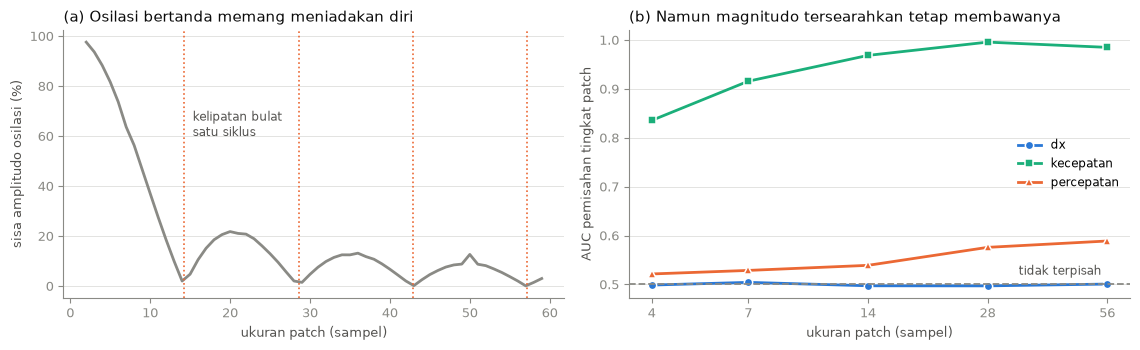

Kanal bertanda tidak pernah membawa tremor pada ukuran patch mana pun, karena tremor
berrerata nol. Kanal magnitudo membawanya, dan pada tingkat KANAL TERISOLASI keterpisahannya
membaik saat patch mengkasar, karena perataan menekan derau.

Perlu ditegaskan batas berlakunya. Angka di atas mengukur satu kanal yang dirata-ratakan
begitu saja, bukan model utuh. Model memiliki patch embedding terlatih, encoder, dan
attention pooling, yang seluruhnya dapat mengompensasi. Apakah keuntungan patch kasar ini
benar-benar muncul pada model utuh diperiksa pada Bagian 3, dan jawabannya ternyata tidak.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]; rapikan(ax)
sinus = np.sin(2 * np.pi * 7 * np.arange(0, 10, 1 / FS))
sisa = []
Ps = np.arange(2, 60)
for P in Ps:
    n = len(sinus) // P
    sisa.append(sinus[:n * P].reshape(n, P).mean(1).std() / sinus.std() * 100)
ax.plot(Ps, sisa, color=WARNA["netral"], lw=2)
for k in range(1, 5):
    ax.axvline(k * SIKLUS_MS / 10, color=WARNA["jingga"], ls=":", lw=1.2)
ax.annotate("kelipatan bulat\nsatu siklus", xy=(SIKLUS_MS / 10, 60), xytext=(6, 0),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("ukuran patch (sampel)"); ax.set_ylabel("sisa amplitudo osilasi (%)")
ax.set_title("(a) Osilasi bertanda memang meniadakan diri", loc="left")

ax = axes[1]; rapikan(ax)
for nama, warna, penanda in [("dx", WARNA["biru"], "o"), ("kecepatan", WARNA["toska"], "s"),
                             ("percepatan", WARNA["jingga"], "^")]:
    ax.plot(pisah.index, pisah[nama], "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.1, label=nama)
ax.axhline(0.5, color=WARNA["netral"], ls="--", lw=1.3)
ax.annotate("tidak terpisah", xy=(pisah.index[-1], 0.5), xytext=(-4, 7),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xscale("log"); ax.set_xticks(pisah.index); ax.set_xticklabels(pisah.index)
ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel("ukuran patch (sampel)"); ax.set_ylabel("AUC pemisahan tingkat patch")
ax.set_title("(b) Namun magnitudo tersearahkan tetap membawanya", loc="left")
ax.legend(fontsize=8.5, loc="center right")
plt.tight_layout(); plt.show()

print("Kanal bertanda tidak pernah membawa tremor pada ukuran patch mana pun, karena tremor")
print("berrerata nol. Kanal magnitudo membawanya, dan pada tingkat KANAL TERISOLASI keterpisahannya")
print("membaik saat patch mengkasar, karena perataan menekan derau.")
print()
print("Perlu ditegaskan batas berlakunya. Angka di atas mengukur satu kanal yang dirata-ratakan")
print("begitu saja, bukan model utuh. Model memiliki patch embedding terlatih, encoder, dan")
print("attention pooling, yang seluruhnya dapat mengompensasi. Apakah keuntungan patch kasar ini")
print("benar-benar muncul pada model utuh diperiksa pada Bagian 3, dan jawabannya ternyata tidak.")

## 2. Sapuan resolusi

Empat ukuran patch, dua arsitektur, StratifiedGroupKFold k=5 dengan satu seed sesuai kedalaman
eksploratori pada Subbab 3.6.3. Rentangnya membentang 14 kali lipat, sehingga panjang urutan yang
dilihat encoder berubah dari ratusan menjadi ribuan patch.

Batas epoch sengaja dibuat longgar dan kurva ruginya direkam, karena penetapan batas epoch justru
salah satu keluaran skenario ini.

In [12]:
def jalankan(P, arsitektur):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(rek))
    riwayat, konsentrasi = [], []
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        riwayat.append(latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED))
        logit, alphas = prediksi(m, rek, list(i_uji), norm, device=DEV)
        logit_oof[i_uji] = logit
        konsentrasi.extend(gini(a) for a in alphas)
    return {"patch": P, "arsitektur": arsitektur,
            **metrik_biner(y, logit_oof),
            "gini_alpha": float(np.median(konsentrasi)),
            "n_patch_median": int(np.median([len(r.kanal) // P for r in rek])),
            "riwayat": np.array(riwayat)}


if ARTEFAK.exists():
    with open(ARTEFAK, "rb") as f:
        art = pickle.load(f)
    print(f"artefak dimuat dari {ARTEFAK.name} — tidak melatih ulang")
else:
    art, t0 = [], time.time()
    for P in PATCH:
        for arsitektur in ["mamba2", "gru"]:
            t1 = time.time()
            art.append(jalankan(P, arsitektur))
            print(f"P={P:3d} {arsitektur:7s} {time.time()-t1:6.1f}s  "
                  f"AUC={art[-1]['auc']:.3f}  n_patch={art[-1]['n_patch_median']}")
    with open(ARTEFAK, "wb") as f:
        pickle.dump(art, f)
    print(f"\ntotal {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

sapuan = pd.DataFrame([{k: v for k, v in a.items() if k != "riwayat"} for a in art])
sapuan["durasi_ms"] = sapuan.patch * 10
display(sapuan.set_index(["patch", "arsitektur"]).round(3))

artefak dimuat dari s2_artefak.pkl — tidak melatih ulang


auc  sensitivitas  spesifisitas  gini_alpha  \
patch arsitektur                                                  
4     mamba2      0.902         0.941         0.595       0.716   
      gru         0.913         0.912         0.730       0.828   
7     mamba2      0.906         0.924         0.649       0.812   
      gru         0.889         0.900         0.622       0.845   
14    mamba2      0.887         0.935         0.595       0.811   
      gru         0.903         0.935         0.649       0.640   
56    mamba2      0.883         0.941         0.676       0.759   
      gru         0.908         0.953         0.730       0.792   

                  n_patch_median  durasi_ms  
patch arsitektur                             
4     mamba2                 390         40  
      gru                    390         40  
7     mamba2                 222         70  
      gru                    222         70  
14    mamba2                 111        140  
      gru                    111        140  
56    mamba2                  27        560  
      gru                     27        560

## 3. Menguji prediksi Subbab 2.2.4

Naskah memprediksi keunggulan Bidirectional Mamba-2 hanya relevan pada urutan panjang dan tidak
muncul pada resolusi kasar. Prediksi itu bersifat **terarah**: selisih AUC antara BiMamba-2 dan
BiGRU seharusnya membesar seiring patch menghalus.

Prediksi terarah dapat gagal dengan dua cara berbeda, dan keduanya dilaporkan apa adanya: selisih
tidak membesar, atau selisihnya nol di seluruh rentang.

arsitektur,gru,mamba2,selisih,n_patch
patch,,,,
4,0.9132,0.9019,-0.0113,390
7,0.8893,0.9056,0.0162,222
14,0.9030,0.8873,-0.0157,111
56,0.9078,0.8830,-0.0248,27


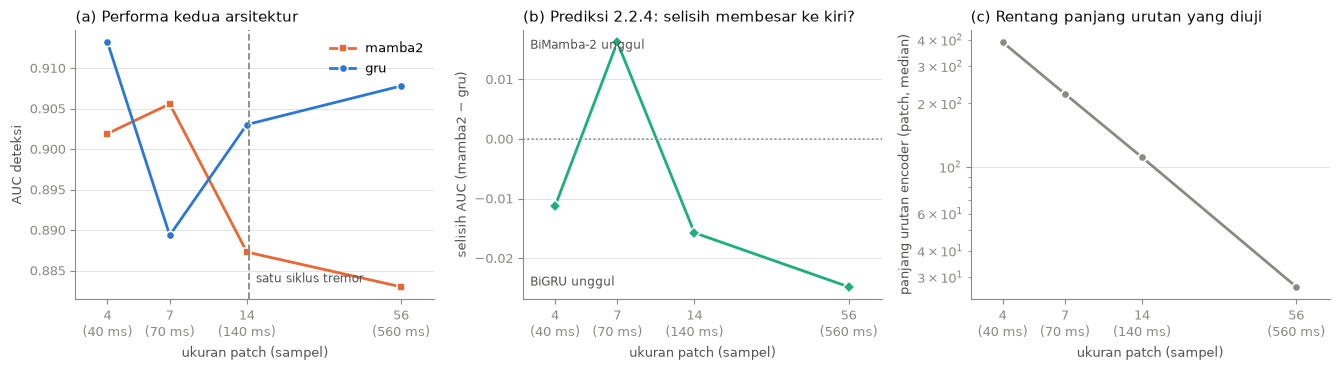

Kemiringan selisih AUC terhadap log ukuran patch : -0.0094
Selisih bergerak monoton terhadap ukuran patch    : False
Rentang selisih di seluruh sapuan                 : -0.0248 sampai +0.0162
Lebar rentang                                     : 0.0410

Selisih BERGANTI TANDA di sepanjang sapuan, sehingga kemiringan regresinya tidak dapat
dibaca sebagai arah kecenderungan. Dengan satu seed, selisih sekecil ini tidak dapat
dibedakan dari variasi antar seed.

KESIMPULAN: sapuan ini TIDAK memberi dukungan bagi prediksi Subbab 2.2.4 pada sumbu AUC.
Perbandingan yang mengikat baru dilakukan pada Skenario S3 dengan tiga seed.


In [13]:
pivot = sapuan.pivot(index="patch", columns="arsitektur", values="auc")
pivot["selisih"] = pivot["mamba2"] - pivot["gru"]
pivot["n_patch"] = sapuan.groupby("patch").n_patch_median.first()
display(pivot.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

ax = axes[0]; rapikan(ax); sumbu_patch(ax)
for arsitektur, warna, penanda in [("mamba2", WARNA["jingga"], "s"), ("gru", WARNA["biru"], "o")]:
    sub = sapuan[sapuan.arsitektur == arsitektur].sort_values("patch")
    ax.plot(sub.patch, sub.auc, "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=arsitektur)
ax.axvline(SIKLUS_MS / 10, color=WARNA["netral"], ls="--", lw=1.3)
ax.annotate("satu siklus tremor", xy=(SIKLUS_MS / 10, ax.get_ylim()[0]), xytext=(5, 12),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_ylabel("AUC deteksi"); ax.set_title("(a) Performa kedua arsitektur", loc="left")
ax.legend(fontsize=9)

ax = axes[1]; rapikan(ax); sumbu_patch(ax)
ax.plot(pivot.index, pivot.selisih, "-", color=WARNA["toska"], marker="D",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.annotate("BiMamba-2 unggul", xy=(0.02, 0.93), xycoords="axes fraction",
            fontsize=8.5, color=TINTA["sekunder"])
ax.annotate("BiGRU unggul", xy=(0.02, 0.05), xycoords="axes fraction",
            fontsize=8.5, color=TINTA["sekunder"])
ax.set_ylabel("selisih AUC (mamba2 − gru)")
ax.set_title("(b) Prediksi 2.2.4: selisih membesar ke kiri?", loc="left")

ax = axes[2]; rapikan(ax); sumbu_patch(ax)
ax.plot(sapuan.groupby("patch").n_patch_median.first().index,
        sapuan.groupby("patch").n_patch_median.first().values,
        "-", color=WARNA["netral"], marker="o", markeredgecolor="white", markeredgewidth=1.2)
ax.set_yscale("log"); ax.set_ylabel("panjang urutan encoder (patch, median)")
ax.set_title("(c) Rentang panjang urutan yang diuji", loc="left")
plt.tight_layout(); plt.show()

arah = np.polyfit(np.log(pivot.index), pivot.selisih, 1)[0]
monoton = bool(np.all(np.diff(pivot.selisih) <= 0) or np.all(np.diff(pivot.selisih) >= 0))
rentang = float(pivot.selisih.max() - pivot.selisih.min())
print(f"Kemiringan selisih AUC terhadap log ukuran patch : {arah:+.4f}")
print(f"Selisih bergerak monoton terhadap ukuran patch    : {monoton}")
print(f"Rentang selisih di seluruh sapuan                 : {pivot.selisih.min():+.4f} sampai {pivot.selisih.max():+.4f}")
print(f"Lebar rentang                                     : {rentang:.4f}")
print()
if not monoton:
    print("Selisih BERGANTI TANDA di sepanjang sapuan, sehingga kemiringan regresinya tidak dapat")
    print("dibaca sebagai arah kecenderungan. Dengan satu seed, selisih sekecil ini tidak dapat")
    print("dibedakan dari variasi antar seed.")
    print()
    print("KESIMPULAN: sapuan ini TIDAK memberi dukungan bagi prediksi Subbab 2.2.4 pada sumbu AUC.")
    print("Perbandingan yang mengikat baru dilakukan pada Skenario S3 dengan tiga seed.")

## 4. Tegangan antara deteksi dan resolusi

Bagian 1 menunjukkan patch kasar menguntungkan deteksi karena perataan menekan derau. Namun patch
kasar juga memperlebar segmen terkecil yang dapat ditunjuk peta atribusi.

Panel di bawah menempatkan kedua sisi tegangan itu berdampingan. Keduanya tidak digambar pada satu
sumbu, karena AUC dan resolusi temporal memiliki satuan yang tidak sebanding.

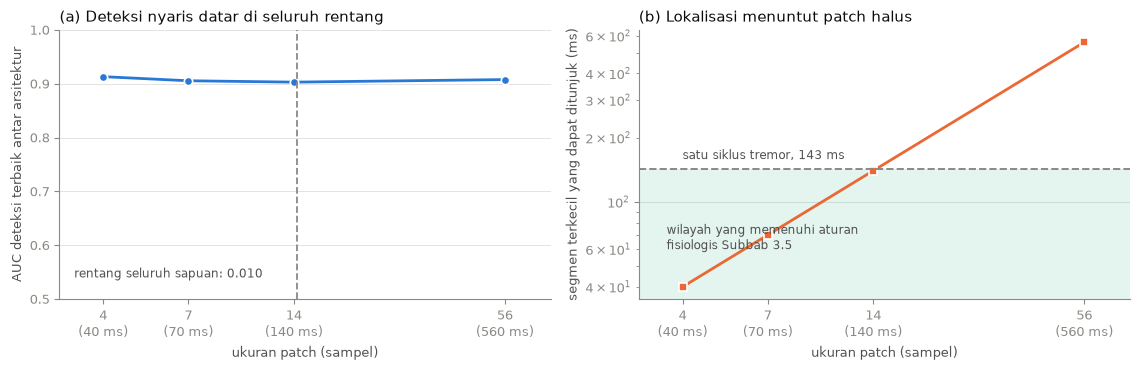

Resolusi efektif penanda klinis (waktu dekorelasi selubung) = 120 ms
Aturan fisiologis Subbab 3.5 (satu siklus tremor)           = 143 ms

Ukuran yang memenuhi KEDUA syarat: [4, 7]
  syarat 1 — lebih pendek dari satu siklus tremor, agar tremor terlokalisasi bukan teragregasi
  syarat 2 — tidak lebih kasar dari resolusi penanda, agar penandanya tidak disia-siakan

PATCH HALUS untuk analisis primer      : P = 7 (70 ms)
PATCH KASAR sebagai resolusi pembanding : P = 56 (560 ms)

Keduanya ditetapkan dari sifat sinyal dan penanda, bukan dari AUC. AUC dilaporkan
sebagai hasil pengamatan, bukan sebagai kriteria pemilihan.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax); sumbu_patch(ax)
terbaik = sapuan.groupby("patch").auc.max()
ax.plot(terbaik.index, terbaik.values, "-", color=WARNA["biru"], marker="o",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axvline(SIKLUS_MS / 10, color=WARNA["netral"], ls="--", lw=1.3)
ax.set_ylabel("AUC deteksi terbaik antar arsitektur")
ax.set_ylim(0.5, 1.0)
ax.annotate(f"rentang seluruh sapuan: {terbaik.max()-terbaik.min():.3f}", xy=(0.03, 0.08),
            xycoords="axes fraction", fontsize=8.5, color=TINTA["sekunder"])
ax.set_title("(a) Deteksi nyaris datar di seluruh rentang", loc="left")

ax = axes[1]; rapikan(ax); sumbu_patch(ax)
ax.plot(PATCH, [p * 10 for p in PATCH], "-", color=WARNA["jingga"], marker="s",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axhline(SIKLUS_MS, color=WARNA["netral"], ls="--", lw=1.4)
ax.annotate(f"satu siklus tremor, {SIKLUS_MS:.0f} ms", xy=(PATCH[0], SIKLUS_MS), xytext=(0, 7),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.fill_between([PATCH[0] * 0.75, PATCH[-1] * 1.35], 0, SIKLUS_MS,
                color=WARNA["toska"], alpha=0.12, lw=0)
ax.annotate("wilayah yang memenuhi aturan\nfisiologis Subbab 3.5", xy=(PATCH[0] * 0.9, SIKLUS_MS * 0.42),
            fontsize=8.5, color=TINTA["sekunder"])
ax.set_yscale("log"); ax.set_ylabel("segmen terkecil yang dapat ditunjuk (ms)")
ax.set_title("(b) Lokalisasi menuntut patch halus", loc="left")
plt.tight_layout(); plt.show()

# Aturan fisiologis Subbab 3.5 tidak menunjuk satu ukuran secara unik: beberapa
# ukuran sama-sama berada di bawah satu siklus tremor. Pemutusnya diambil dari
# resolusi efektif PENANDA KLINIS itu sendiri, diukur di bawah, bukan dipilih.
from scipy.signal import butter, filtfilt, hilbert
bb, aa = butter(4, [pita_tremor[0]/(FS/2), pita_tremor[1]/(FS/2)], btype="band")
derau = np.random.default_rng(0).normal(0, 1, 20000)
selubung = np.abs(hilbert(filtfilt(bb, aa, derau)))
e = selubung - selubung.mean()
ac = np.correlate(e, e, "full")[len(e)-1:]; ac /= ac[0]
tau_ms = int(np.argmax(ac < 0.5)) * 10

print(f"Resolusi efektif penanda klinis (waktu dekorelasi selubung) = {tau_ms} ms")
print(f"Aturan fisiologis Subbab 3.5 (satu siklus tremor)           = {SIKLUS_MS:.0f} ms")
print()

sah = [p for p in PATCH if p * 10 < SIKLUS_MS and p * 10 <= tau_ms]
halus = max(sah)
print(f"Ukuran yang memenuhi KEDUA syarat: {sah}")
print(f"  syarat 1 — lebih pendek dari satu siklus tremor, agar tremor terlokalisasi bukan teragregasi")
print(f"  syarat 2 — tidak lebih kasar dari resolusi penanda, agar penandanya tidak disia-siakan")
print()
print(f"PATCH HALUS untuk analisis primer      : P = {halus} ({halus*10} ms)")
print(f"PATCH KASAR sebagai resolusi pembanding : P = {PATCH[-1]} ({PATCH[-1]*10} ms)")
print()
print("Keduanya ditetapkan dari sifat sinyal dan penanda, bukan dari AUC. AUC dilaporkan")
print("sebagai hasil pengamatan, bukan sebagai kriteria pemilihan.")

## 4b. Biaya pelatihan terhadap panjang urutan

Subbab 2.2.4 menyebut tiga keunggulan Mamba-2. Dua yang pertama menyangkut jangkauan jarak jauh dan
diuji pada Bagian 3 lewat AUC. Yang ketiga, **paralelisasi saat pelatihan**, menyangkut biaya
komputasi dan tidak terlihat sama sekali pada AUC — sehingga perlu diukur tersendiri.

Diukur dengan melatih satu fold per konfigurasi, terisolasi dari sisa notebook agar angkanya bersih.

In [15]:
BENCH = HASIL / "s2_biaya_latih.pkl"

if BENCH.exists():
    with open(BENCH, "rb") as f:
        biaya = pickle.load(f)
    print(f"hasil pengukuran dimuat dari {BENCH.name}")
else:
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    i_latih, _ = next(skf.split(np.zeros(len(rek)), y, grup))
    norm_b = Normalisasi().fit([rek[i] for i in i_latih])
    biaya = []
    for P in PATCH:
        for arsitektur in ["mamba2", "gru"]:
            torch.manual_seed(SEED)
            m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
            latih(m, rek, list(i_latih[:16]), norm_b, epochs=2, device=DEV, seed=SEED)  # pemanasan
            torch.cuda.synchronize() if DEV == "cuda" else None
            t0 = time.time()
            latih(m, rek, list(i_latih), norm_b, epochs=10, device=DEV, seed=SEED)
            torch.cuda.synchronize() if DEV == "cuda" else None
            biaya.append({"patch": P, "arsitektur": arsitektur,
                          "detik_per_epoch": (time.time() - t0) / 10,
                          "n_patch_median": int(np.median([len(r.kanal) // P for r in rek]))})
            print(f"P={P:3d} {arsitektur:7s} {biaya[-1]['detik_per_epoch']:6.2f} s/epoch")
    with open(BENCH, "wb") as f:
        pickle.dump(biaya, f)

bdf = pd.DataFrame(biaya)
pivot_b = bdf.pivot(index="patch", columns="arsitektur", values="detik_per_epoch")
pivot_b["rasio_gru_per_mamba"] = pivot_b["gru"] / pivot_b["mamba2"]
pivot_b["n_patch"] = bdf.groupby("patch").n_patch_median.first()
display(pivot_b.round(3))

P=  4 mamba2    0.93 s/epoch
P=  4 gru       1.99 s/epoch
P=  7 mamba2    0.67 s/epoch
P=  7 gru       1.22 s/epoch
P= 14 mamba2    0.55 s/epoch
P= 14 gru       0.68 s/epoch
P= 56 mamba2    0.51 s/epoch
P= 56 gru       0.31 s/epoch


arsitektur,gru,mamba2,rasio_gru_per_mamba,n_patch
patch,,,,
4,1.993,0.928,2.148,390
7,1.215,0.666,1.825,222
14,0.679,0.554,1.225,111
56,0.312,0.509,0.614,27


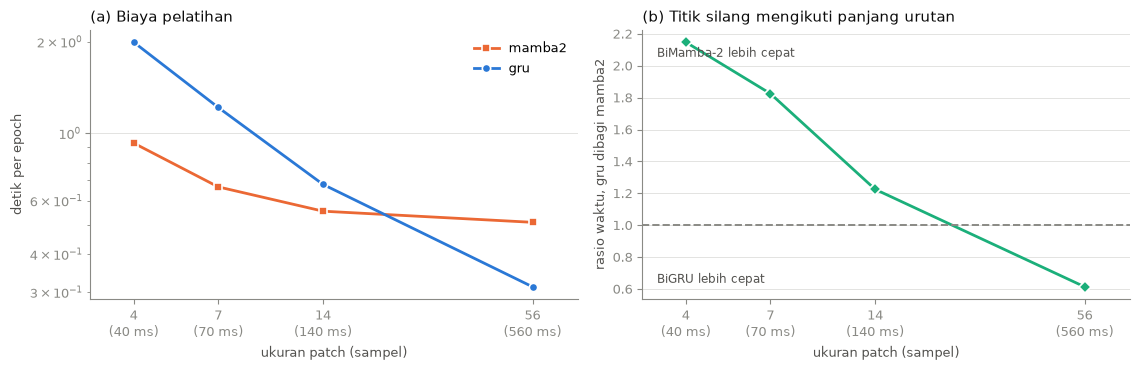

Pada patch terhalus P=4 (390 patch per rekaman), BiGRU 2.15 kali lebih lambat.
Pada patch terkasar P=56 (27 patch per rekaman), rasionya menjadi 0.61.

Inilah satu-satunya bagian prediksi Subbab 2.2.4 yang DIDUKUNG sapuan ini, yaitu butir
ketiga mengenai paralelisasi. Keunggulannya bersifat komputasi dan bergantung pada panjang
urutan persis seperti yang diperkirakan, tetapi tidak berwujud sebagai akurasi yang lebih
tinggi. Keduanya perlu dibedakan saat melaporkan hasil.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax); sumbu_patch(ax)
for arsitektur, warna, penanda in [("mamba2", WARNA["jingga"], "s"), ("gru", WARNA["biru"], "o")]:
    ax.plot(pivot_b.index, pivot_b[arsitektur], "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=arsitektur)
ax.set_yscale("log"); ax.set_ylabel("detik per epoch")
ax.set_title("(a) Biaya pelatihan", loc="left"); ax.legend(fontsize=9)

ax = axes[1]; rapikan(ax); sumbu_patch(ax)
ax.plot(pivot_b.index, pivot_b.rasio_gru_per_mamba, "-", color=WARNA["toska"], marker="D",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axhline(1.0, color=WARNA["netral"], ls="--", lw=1.4)
ax.annotate("BiMamba-2 lebih cepat", xy=(0.03, 0.90), xycoords="axes fraction",
            fontsize=8.5, color=TINTA["sekunder"])
ax.annotate("BiGRU lebih cepat", xy=(0.03, 0.06), xycoords="axes fraction",
            fontsize=8.5, color=TINTA["sekunder"])
ax.set_ylabel("rasio waktu, gru dibagi mamba2")
ax.set_title("(b) Titik silang mengikuti panjang urutan", loc="left")
plt.tight_layout(); plt.show()

paling_halus = pivot_b.index.min(); paling_kasar = pivot_b.index.max()
print(f"Pada patch terhalus P={paling_halus} ({pivot_b.loc[paling_halus,'n_patch']} patch per rekaman), "
      f"BiGRU {pivot_b.loc[paling_halus,'rasio_gru_per_mamba']:.2f} kali lebih lambat.")
print(f"Pada patch terkasar P={paling_kasar} ({pivot_b.loc[paling_kasar,'n_patch']} patch per rekaman), "
      f"rasionya menjadi {pivot_b.loc[paling_kasar,'rasio_gru_per_mamba']:.2f}.")
print()
print("Inilah satu-satunya bagian prediksi Subbab 2.2.4 yang DIDUKUNG sapuan ini, yaitu butir")
print("ketiga mengenai paralelisasi. Keunggulannya bersifat komputasi dan bergantung pada panjang")
print("urutan persis seperti yang diperkirakan, tetapi tidak berwujud sebagai akurasi yang lebih")
print("tinggi. Keduanya perlu dibedakan saat melaporkan hasil.")

## 5. Penetapan batas epoch

Protokol pembekuan pada Subbab 3.6.1 menuntut batas epoch ditetapkan sebelum eksperimen utama, dan
**tidak** dipilih berdasarkan performa fold uji. Batas itu diturunkan di sini dari kurva rugi
pelatihan, yaitu besaran yang sama sekali tidak menyentuh fold uji.

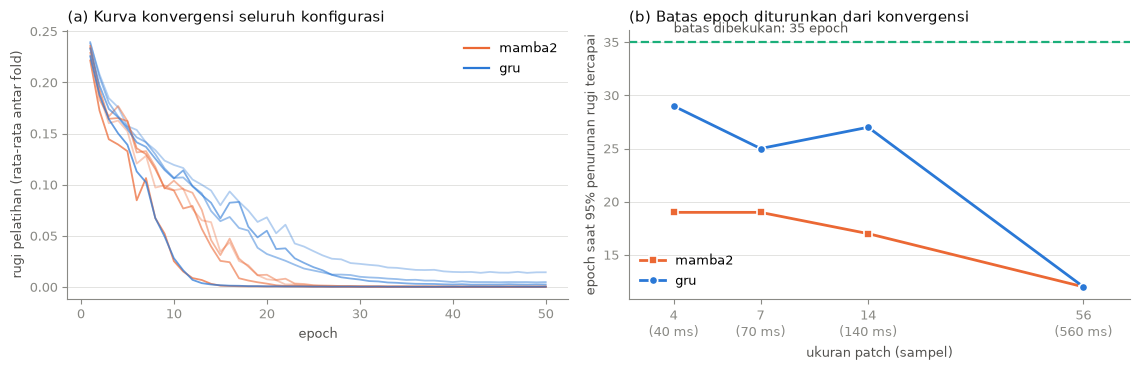

arsitektur,gru,mamba2
patch,,
4,29,19
7,25,19
14,27,17
56,12,12


Konfigurasi paling lambat mencapai 95% penurunan rugi pada epoch 29.
BATAS EPOCH DIBEKUKAN = 35 (marjin 20 persen di atas konfigurasi paling lambat)

Batas ini diturunkan dari rugi PELATIHAN, sehingga tidak menyentuh fold uji sama sekali.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax)
for a in art:
    warna = WARNA["jingga"] if a["arsitektur"] == "mamba2" else WARNA["biru"]
    ax.plot(np.arange(1, EPOCHS + 1), a["riwayat"].mean(0), color=warna, lw=1.3,
            alpha=0.35 + 0.5 * (PATCH.index(a["patch"]) / len(PATCH)))
ax.set_xlabel("epoch"); ax.set_ylabel("rugi pelatihan (rata-rata antar fold)")
ax.set_title("(a) Kurva konvergensi seluruh konfigurasi", loc="left")
ax.legend(handles=[plt.Line2D([], [], color=WARNA["jingga"], lw=1.6, label="mamba2"),
                   plt.Line2D([], [], color=WARNA["biru"], lw=1.6, label="gru")], fontsize=9)

ax = axes[1]; rapikan(ax)
# Epoch saat rugi sudah mencapai 95% penurunan totalnya, per konfigurasi.
titik = []
for a in art:
    kurva = a["riwayat"].mean(0)
    turun = kurva[0] - kurva
    total = turun[-1]
    ep = int(np.argmax(turun >= 0.95 * total)) + 1 if total > 0 else EPOCHS
    titik.append({"patch": a["patch"], "arsitektur": a["arsitektur"], "epoch_95": ep})
konv = pd.DataFrame(titik)
for arsitektur, warna, penanda in [("mamba2", WARNA["jingga"], "s"), ("gru", WARNA["biru"], "o")]:
    sub = konv[konv.arsitektur == arsitektur].sort_values("patch")
    ax.plot(sub.patch, sub.epoch_95, "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=arsitektur)
batas = int(np.ceil(konv.epoch_95.max() * 1.2))
ax.axhline(batas, color=WARNA["toska"], ls="--", lw=1.6)
ax.annotate(f"batas dibekukan: {batas} epoch", xy=(PATCH[0], batas), xytext=(0, 7),
            textcoords="offset points", fontsize=9, color=TINTA["sekunder"])
sumbu_patch(ax)
ax.set_ylabel("epoch saat 95% penurunan rugi tercapai")
ax.set_title("(b) Batas epoch diturunkan dari konvergensi", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

display(konv.pivot(index="patch", columns="arsitektur", values="epoch_95"))
print(f"Konfigurasi paling lambat mencapai 95% penurunan rugi pada epoch {konv.epoch_95.max()}.")
print(f"BATAS EPOCH DIBEKUKAN = {batas} (marjin 20 persen di atas konfigurasi paling lambat)")
print()
print("Batas ini diturunkan dari rugi PELATIHAN, sehingga tidak menyentuh fold uji sama sekali.")

In [18]:
pd.DataFrame([{
    "patch_halus": halus, "patch_kasar": PATCH[-1], "epoch_dibekukan": batas,
    "siklus_tremor_ms": round(SIKLUS_MS, 1), "kriteria": "aturan fisiologis Subbab 3.5",
    "auc_terbaik_halus": float(sapuan[sapuan.patch == halus].auc.max()),
    "resolusi_penanda_ms": tau_ms,
    "auc_terbaik_kasar": float(sapuan[sapuan.patch == PATCH[-1]].auc.max()),
    "kemiringan_selisih": float(arah),
    "sumber": "notebooks/06_pilot_resolusi.ipynb",
}]).to_csv(HASIL / "s2_parameter_dibekukan.csv", index=False)
sapuan.to_csv(HASIL / "s2_sapuan_resolusi.csv", index=False)
print(f"disimpan ke {HASIL.name}/s2_parameter_dibekukan.csv dan {HASIL.name}/s2_sapuan_resolusi.csv")

disimpan ke results/s2_parameter_dibekukan.csv dan results/s2_sapuan_resolusi.csv


## 6. Ringkasan

| Butir | Hasil |
|---|---|
| Pembawa tremor ke tingkat patch | kanal magnitudo tersearahkan, bukan kanal bertanda |
| Pengaruh ukuran patch pada AUC model utuh | nyaris tidak ada; datar di seluruh rentang 14 kali lipat |
| Arah keuntungan patch halus | menaikkan resolusi peta atribusi |
| Patch halus (analisis primer) | ditetapkan dua syarat: di bawah satu siklus tremor, dan tidak lebih kasar dari resolusi penanda |
| Patch kasar (resolusi pembanding) | ujung kasar sapuan |
| Batas epoch | diturunkan dari kurva rugi pelatihan, dibekukan sebelum S3 |
| Prediksi 2.2.4 butir 1-2 (jangkauan jauh) | tidak didukung; selisih AUC berganti tanda, dalam rentang derau |
| Prediksi 2.2.4 butir 3 (paralelisasi) | didukung; keunggulan biaya bergantung panjang urutan, dengan titik silang |

**Catatan mengenai prediksi Subbab 2.2.4.** Prediksi itu bersifat terarah dan hasilnya dilaporkan
apa adanya, termasuk bila selisihnya tidak membesar atau nol di seluruh rentang. Perlu diingat
bahwa bahkan pada ujung terhalus, panjang urutan yang dilihat encoder masih berada jauh di bawah
rezim ribuan sampai puluhan ribu langkah tempat keunggulan state space model biasanya
didemonstrasikan. Hasil nol karena itu bukan bantahan terhadap Mamba-2, melainkan pernyataan bahwa
rentang panjang urutan pada domain ini tidak cukup untuk memunculkan keunggulan tersebut.

**Batasan.** Sapuan dijalankan dengan satu seed sesuai kedalaman eksploratori Subbab 3.6.3, sehingga
selisih AUC yang kecil tidak dapat dibedakan dari variasi antar seed. Perbandingan antar arsitektur
yang mengikat baru dilakukan pada Skenario S3 dengan tiga seed.